# Supplementary Activity:

### Setup

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import matplotlib as mpl

%matplotlib inline

fb = pd.read_csv('/Users/macbookpro/CPE-311/HOA/HOA 9.1/Datasets/fb_stock_prices_2018.csv', index_col='date', parse_dates=True)

quakes = pd.read_csv('/Users/macbookpro/CPE-311/HOA/HOA 9.1/Datasets/earthquakes-1.csv')

In [32]:
print("Facebook data shape:", fb.shape)
fb.head()

Facebook data shape: (251, 5)


,open,high,low,close,volume
date,,,,,
2018-01-02,177.68,181.58,177.5500,181.42,18151903
2018-01-03,181.88,184.78,181.3300,184.67,16886563
2018-01-04,184.90,186.21,184.0996,184.33,13880896
2018-01-05,185.59,186.90,184.9300,186.85,13574535
2018-01-08,187.20,188.90,186.3300,188.28,17994726


In [33]:
print("Earthquake data shape:", quakes.shape)
quakes.head()

Earthquake data shape: (9332, 6)


,mag,magType,time,place,tsunami,parsed_place
0,1.35,ml,1539475168010,"9km NE of Aguanga, CA",0,California
1,1.29,ml,1539475129610,"9km NE of Aguanga, CA",0,California
2,3.42,ml,1539475062610,"8km NE of Aguanga, CA",0,California
3,0.44,ml,1539474978070,"9km NE of Aguanga, CA",0,California
4,2.16,md,1539474716050,"10km NW of Avenal, CA",0,California


## Supplementary Activity

Using the CSV files provided and what we have learned so far in this module complete the following exercises:

1. Plot the rolling 20-day minimum of the Facebook closing price with the pandas plot() method.

2. Create a histogram and KDE of the change from open to close in the price of Facebook stock.

3. Using the earthquake data, create box plots for the magnitudes of each magType used in Indonesia.

4. Make a line plot of the difference between the weekly maximum high price and the weekly minimum low price for Facebook. This should be a single
line.

5. Using matplotlib and pandas, create two subplots side-by-side showing the effect that after-hours trading has had on Facebook's stock price:

- The first subplot will contain a line plot of the daily difference between that day's opening price and the prior day's closing price (be sure to review the Time series section of Aggregating Pandas DataFrames for an easy way to do this).

- The second subplot will be a bar plot showing the net effect this had monthly, using resample().

- Bonus #1: Color the bars according to whether they are gains in the stock price (green) or drops in the stock price (red).

- Bonus #2: Modify the x-axis of the bar plot to show the threeletter abbreviation for the month.



Text(0, 0.5, 'Price ($)')

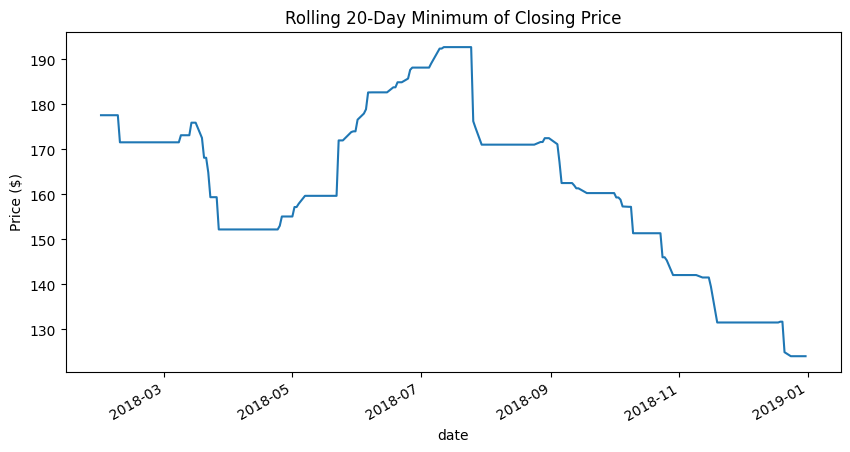

In [34]:
# 1.
fb['close'].rolling(window=20).min().plot(figsize=(10,5),title='Rolling 20-Day Minimum of Closing Price')
plt.ylabel('Price ($)')

#### Comment:
- The rolling minimum smooths out the daily fluctuations and shows the lowest closing price over the past 20 days.

Text(0.5, 0, 'Change ($)')

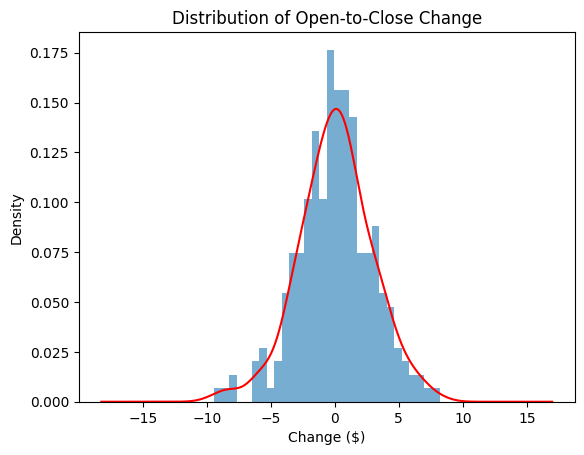

In [35]:
# 2.
fb['open_close_change'] = fb.close - fb.open
ax = fb['open_close_change'].plot(kind='hist', density=True, bins=30, alpha=0.6,title='Distribution of Open-to-Close Change')
fb['open_close_change'].plot(kind='kde', ax=ax, color='red')
plt.xlabel('Change ($)')

#### Comment: 
- The distribution is centered near zero, indicating that most days the price doesn't change dramatically. Some positive and negative tails.

Text(0, 0.5, 'Magnitude')

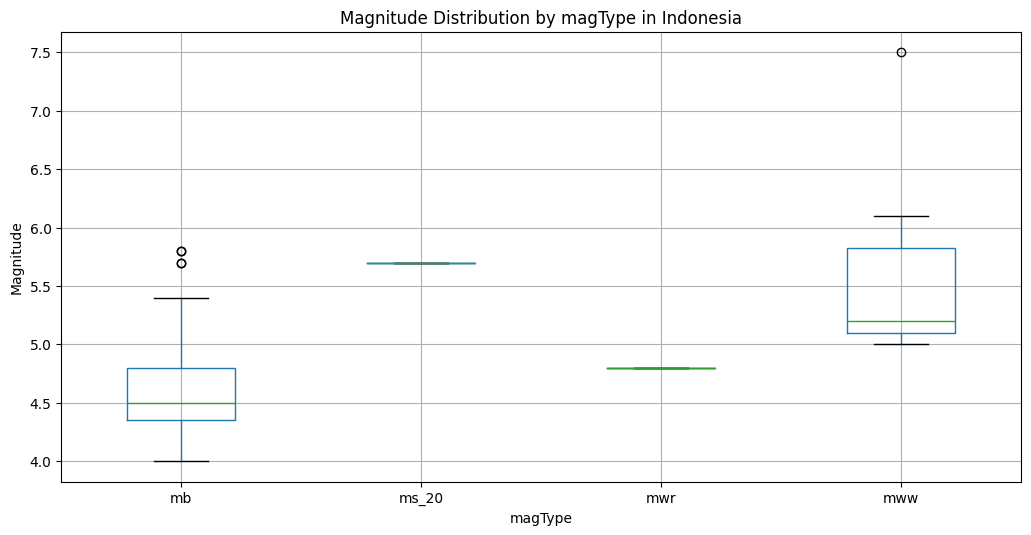

In [36]:
# 3.
indonesia = quakes[quakes['place'].str.contains('Indonesia', na=False)]

indonesia.boxplot(column='mag', by='magType', figsize=(12,6))
plt.suptitle('')
plt.title('Magnitude Distribution by magType in Indonesia')
plt.ylabel('Magnitude')

#### Comment:
- In Indonesia, the 'mb' and 'mww' types have higher magnitudes on average. Some types have few data points.

Text(0, 0.5, 'Price Difference ($)')

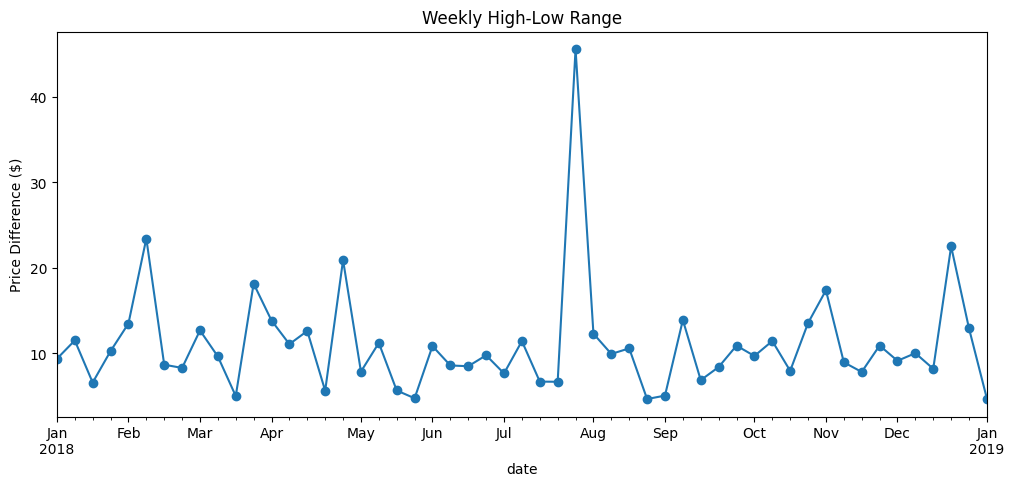

In [37]:
# 4.
weekly_max_high = fb['high'].resample('W').max()
weekly_min_low = fb['low'].resample('W').min()
weekly_diff = weekly_max_high - weekly_min_low

weekly_diff.plot(figsize=(12,5), marker='o', title='Weekly High-Low Range')
plt.ylabel('Price Difference ($)')

#### Comment:
- The weekly range fluctuates; some weeks have high volatility (large range), others are calm.

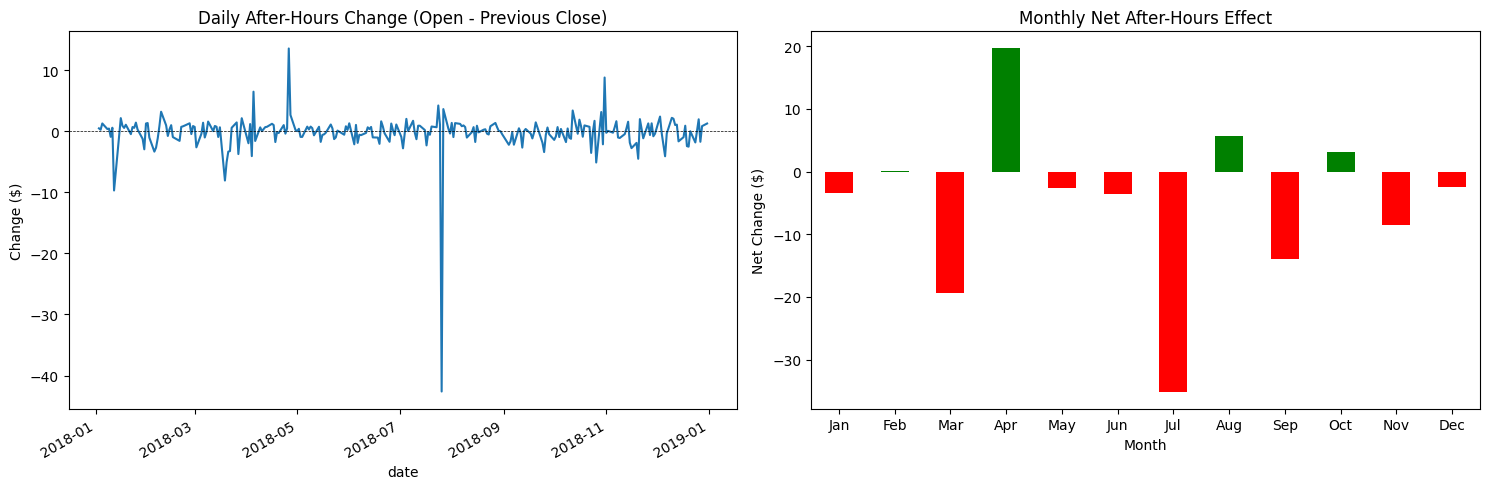

In [38]:
# 5.
fb['after_hours'] = fb['open'] - fb['close'].shift(1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

fb['after_hours'].plot(ax=ax1, title='Daily After-Hours Change (Open - Previous Close)')
ax1.set_ylabel('Change ($)')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.5)

monthly_effect = fb['after_hours'].resample('ME').sum()
colors = ['green' if x >= 0 else 'red' for x in monthly_effect]
monthly_effect.plot(kind='bar', ax=ax2, color=colors, title='Monthly Net After-Hours Effect')
ax2.set_ylabel('Net Change ($)')
ax2.set_xlabel('Month')

month_abbr = [date.strftime('%b') for date in monthly_effect.index]
ax2.set_xticklabels(month_abbr, rotation=0)

plt.tight_layout()

#### Comment: 
- The daily after-hours change fluctuates around zero, with some spikes.
- Monthly net effect shows which months had overall positive or negative after-hours movement. Bars are colored green for gains, red for losses.
- Month abbreviations are displayed on x-axis.

## Conclusion:

I feel like I learned a lot about making charts and graphs using Matplotlib and Pandas in this activity. I got to try out different kinds of plots starting from simple line graphs all the way to more complicated ones like scatter matrices and lag plots. It was pretty cool seeing how we can visualize data in so many different ways.

What I realized is that Matplotlib lets you control pretty much everything about your plot if you want to get specific with it. But Pandas makes things easier since you can just type .plot() and it does a lot of the work for you. Understanding the difference between the Figure and Axes stuff was a bit confusing at first but it makes sense now when you want to arrange multiple graphs together.

Using real data like Facebook stock prices and earthquake info made it more interesting because you could actually see patterns and trends. Like how stock prices move over time or where earthquakes usually happen. The graphs really help you spot things you might miss if you're just looking at numbers in a table.

The exercises at the end were helpful too because they made me apply what I learned to solve actual problems. Figuring out how to show the after-hours trading effect with the green and red bars was tricky but satisfying when it worked. Stuff like rolling averages and box plots seem like they'll be pretty useful for other projects too.

Honestly I think being able to make good graphs is a solid skill to have. Whether it's for school projects or eventually work stuff, knowing how to show data in a clear way helps other people understand what you're trying to say. 